Chatbot Creating New Memories and Remembering old memories and what should be stored

In [1]:
from dotenv import load_dotenv
import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START,END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [2]:
#1. Creating LLM Store

store = InMemoryStore()

In [3]:
#2. System prompt

SYSTEM_PROMPT_TEMPLATE = """
You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [ ]:
#3. Memory  Extraction LLM

memory_llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash",temperature= 0)

In [5]:
class MemoryItem(BaseModel):
    text : str = Field(description="Atomic user memory")
    is_new : bool = Field(description="True if new, false if duplicate")

In [6]:
class MemoryDecision(BaseModel):
    should_write : bool = Field(description="checks if  the message should be noted inside store or not")
    memories : List[MemoryItem] =Field(default_factory= list ,description="Atomic user memories to store")

In [7]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [8]:
MEMORY_PROMPT = """
You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return should_write=false and an empty list.
"""

In [11]:
#4. Remember Node
def remember_node(state:MessagesState,config:RunnableConfig,*,store:BaseStore):
    user_id = config['configurable']['user_id']
    namespace = ("user",user_id,"details")
    
    #extracting Existing memory
    existing_items =  store.search(namespace)
    existing_texts = "\n".join(item.value["data"] for item in existing_items) if existing_items else "(empty)"
    
    #recent message
    last_message = state["messages"][-1].content
    
    #decison
    decision :MemoryDecision = memory_extractor.invoke([
        SystemMessage(content = MEMORY_PROMPT.format(user_details_content = existing_texts)),
        {"role":"user","content":last_message},
    ])
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace,str(uuid.uuid4()),{"data":mem.text})
    return {} #no message sent

In [12]:
#llm for chat
chat_llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash",temperature=0)

In [13]:
#chat node
def chat_node(state:MessagesState,config:RunnableConfig,*,store:BaseStore):
    user_id = config['configurable']['user_id']
    namespace = ("user",user_id,"details")
    
    items = store.search(namespace)
    
    user_details = "\n".join(item.value["data"] for item in items) if items else ""
    system_message = SystemMessage(content=SYSTEM_PROMPT_TEMPLATE.format(user_details_content=  user_details or "(empty)"))
    
    response = chat_llm.invoke([system_message] + state["messages"])
    
    return {"messages":[response]} 

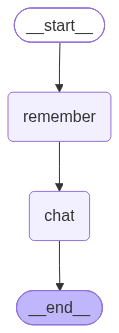

In [14]:
#6. building GRAPH

builder = StateGraph(MessagesState)
builder.add_node("chat",chat_node)
builder.add_node("remember",remember_node)

builder.add_edge(START,"remember")
builder.add_edge("remember","chat")
builder.add_edge('chat',END)

graph = builder.compile(store=store)

graph

In [15]:
#DEMO

config = {"configurable": {"user_id": "u1"}}

In [16]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Nazia"}]}, config)
result['messages'][-1].content

"Hello Nazia! It's great to meet you. I've made a note of your name.\n\nHow can I help you today, Nazia?\n\nHere are a few things you might want to ask:\n1. What kind of tasks can you help me with?\n2. Can you tell me a fun fact?\n3. What's the weather like today?"

In [17]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

The user's name is Nazia.


In [18]:
result = graph.invoke({"messages": [{"role": "user", "content": "A software developer who is an AI enthusiast"}]}, config)
print(result['messages'][-1].content)

Thanks for letting me know, Nazia! I've updated my memory. So, you're a software developer with a passion for AI – that's a fantastic combination!

It's great to have that context. How can I assist you today, Nazia, perhaps with something related to AI development, software engineering, or anything else that sparks your interest?

Here are a few questions you might consider:

1.  Are there any specific AI topics or frameworks you're currently exploring, Nazia?
2.  What kind of software development projects are you typically involved in?
3.  Would you like to discuss recent advancements in AI or perhaps some best practices for integrating AI into software?


In [19]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

The user's name is Nazia.
The user is a software developer.
The user is an AI enthusiast.


In [20]:

result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Hello Nazia! As a fellow AI enthusiast and software developer, I'd be happy to explain Generative AI (GenAI) simply for you.

Think of it this way:

**Generative AI is a type of artificial intelligence that can *create* brand new things.**

Unlike traditional AI that might analyze data, classify it, or make predictions based on existing information, GenAI goes a step further. It learns from a massive amount of existing data (like text, images, code, or music) to understand the underlying patterns, styles, and structures. Once it "gets" these patterns, it can then use that knowledge to **generate original, never-before-seen content** that fits those learned characteristics.

Here's a quick breakdown:

1.  **It Learns:** It studies tons of examples (e.g., millions of sentences, images, or lines of code).
2.  **It Understands Patterns:** It figures out the rules, styles, and relationships within that data.
3.  **It Creates:** Using those learned patterns, it can then produce something ent

In [21]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

The user's name is Nazia.
The user is a software developer.
The user is an AI enthusiast.
